# Double Gauss — Chief-Ray Distortion

A four-element double-Gauss photographic objective (the classic
Zeiss-Planar-derived form: two meniscus pairs symmetric about a central
aperture stop). Prescription reconstructed from the "four element double
gauss, intermediate optical design" reference lens distributed with the
open-source [rayopt-notebooks](https://github.com/quartiq/rayopt-notebooks)
project (`double_gauss.ipynb`); glass indices (SK4, F4) are d-line
(587.6 nm) values from the SCHOTT optical glass pocket catalog. It is a
textbook-scale example, not a claim of a specific commercial lens.

Unlike the [Cooke triplet](cooke_triplet.ipynb), this design's stop sits
at the geometric center of an (almost) mirror-symmetric element layout —
the classic reason double-Gauss lenses run distortion an order of
magnitude lower than an asymmetric triplet at a comparable field angle.
This notebook measures that directly, both as a dense distortion-vs-field
curve and as a warped-grid display, and the two notebooks are meant to be
read side by side.

In [1]:
from importlib import resources
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from raytracer.sequential import (
    FieldPoint, OpticalSystem, ParaxialModel, SequentialTracer,
    chief_ray_slopes, solve_object_plane, trace_from_object,
)
from raytracer.analysis import distortion_grid
from raytracer.viz import plots

CSV = resources.files("raytracer") / "data" / "double_gauss_prescription.csv"
system = OpticalSystem.from_prescription(CSV)
tracer = SequentialTracer(system)
conjugate = solve_object_plane(tracer)
efl = ParaxialModel(system).effective_focal_length()

print(f"{len(system)} surfaces, stop at index {system.stop_index}")
print(f"EFL = {efl:.3f} mm")
print(f"recovered object plane z = {conjugate.object_z:.1f} mm "
      f"(a large finite stand-in for the design's object at infinity)")
print(f"magnification = {conjugate.magnification:.6f}")

9 surfaces, stop at index 4
EFL = 98.951 mm
recovered object plane z = -10672.1 mm (a large finite stand-in for the design's object at infinity)
magnification = -0.009347


## Distortion vs. field angle

Same approach as the triplet notebook: field points are parametrized by
angle (the design's own object-angle convention, half field ~20.6°), each
angle converted to an object height at the recovered finite conjugate, and
the chief ray solved with the general 2-D solver `chief_ray_slopes` (no
manual bracket-tuning needed — unlike the coarse 1-D bracket scan used
elsewhere in this package, the general solver converges directly from a
paraxial estimate even for this huge finite-object stand-in for infinity).
Sampled densely (steps of 0.5°) out to the design's stated half field.

 field (deg) |  image y (mm) |  distortion (um) | relative (ppm)
         0.0 |       -0.0000 |            0.000 |            0.0
         4.0 |       -6.9756 |           -0.260 |           37.3
         8.0 |      -14.0197 |           -2.194 |          156.5
        12.0 |      -21.2037 |           -8.070 |          380.6
        16.0 |      -28.6044 |          -21.571 |          754.1
        20.0 |      -36.3081 |          -49.186 |         1354.7


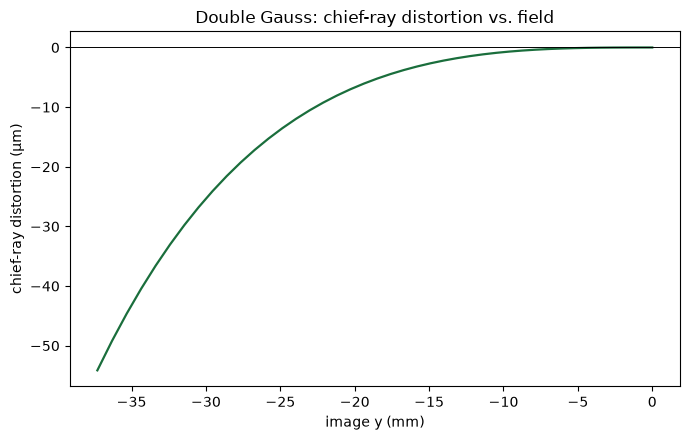

In [2]:
from raytracer.analysis import chief_ray_distortion

FIELDS_DEG = np.arange(0.0, 20.61, 0.5)
rows = chief_ray_distortion(
    tracer, FIELDS_DEG, magnification=conjugate.magnification, field_unit="deg",
)
image_heights = [r["paraxial_image_height_mm"] for r in rows]
distortions_um = [r["chief_ray_distortion_um"] for r in rows]

print(f"{'field (deg)':>12} | {'image y (mm)':>13} | {'distortion (um)':>16} | {'relative (ppm)':>14}")
for r in rows[::8]:
    print(f"{r['field']:12.1f} | {r['paraxial_image_height_mm']:13.4f} | "
          f"{r['chief_ray_distortion_um']:16.3f} | {r['chief_ray_relative_distortion_ppm']:14.1f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(image_heights, distortions_um, "-", color="#1a6e3c", lw=1.6)
ax.axhline(0, color="black", lw=0.7)
ax.set(xlabel="image y (mm)", ylabel="chief-ray distortion (\u00b5m)",
       title="Double Gauss: chief-ray distortion vs. field")
fig.tight_layout()
plt.show()


## Distortion grid

The grid spans the design's ~20.6° half field on each axis.

grid coverage: 100.0% of 121 points traced without vignetting


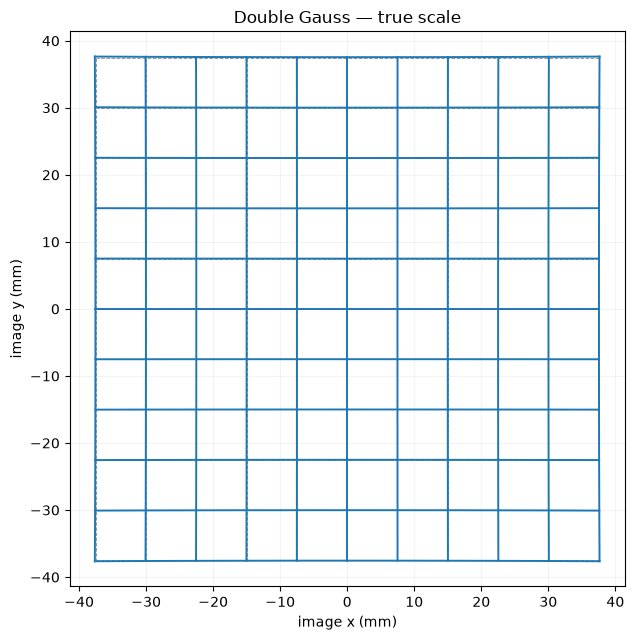

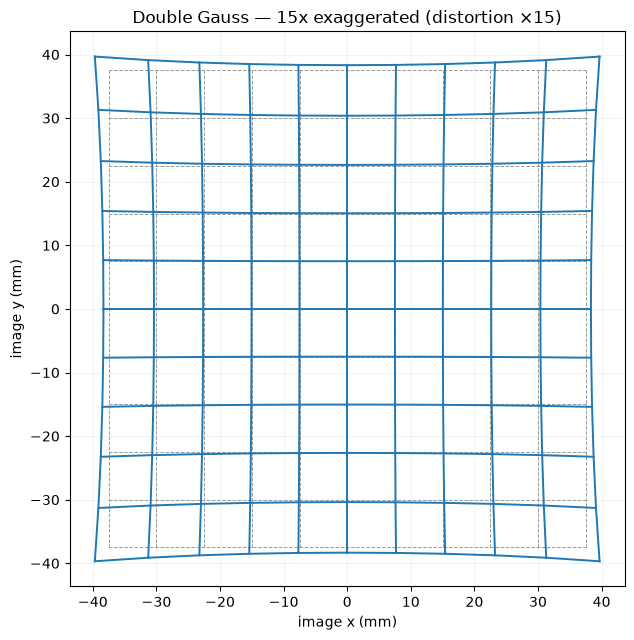

In [3]:
half = abs(conjugate.object_z) * np.tan(np.deg2rad(20.6))
grid = distortion_grid(tracer, magnification=conjugate.magnification, half_field=half, n=11)
print(f"grid coverage: {grid.valid_fraction:.1%} of {grid.valid.size} points traced without vignetting")

fig = plots.distortion_grid_figure(grid, exaggeration=1.0, title="Double Gauss — true scale")
plt.show()
fig = plots.distortion_grid_figure(grid, exaggeration=15.0, title="Double Gauss — 15x exaggerated")
plt.show()

## Triplet vs. double Gauss, at matching field angles

Comparing *relative* distortion (ppm) rather than absolute microns
controls for the two designs' different focal lengths (50 mm vs. ~99 mm)
and lets the stop-symmetry effect show through directly, over the whole
range both designs share (0 to the triplet's 12° sampling limit above).

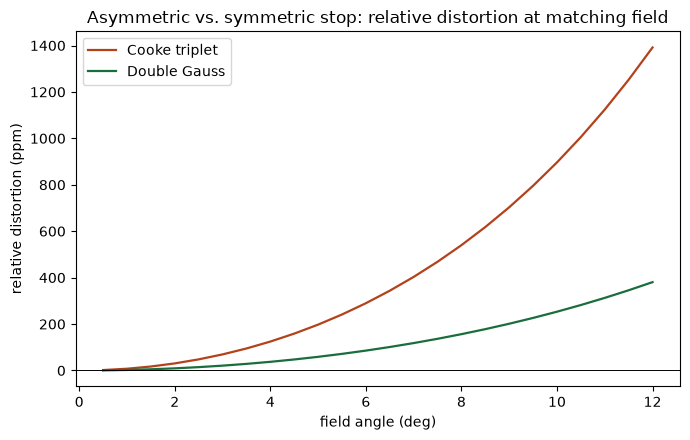

In [4]:
from raytracer.sequential import OpticalSystem as _OS, SequentialTracer as _ST, solve_object_plane as _sop

triplet_csv = resources.files("raytracer") / "data" / "cooke_triplet_prescription.csv"
triplet_system = _OS.from_prescription(triplet_csv)
triplet_tracer = _ST(triplet_system)
triplet_conjugate = _sop(triplet_tracer)

COMMON_FIELDS_DEG = np.arange(0.5, 12.01, 0.5)
triplet_ppm = [r["chief_ray_relative_distortion_ppm"] for r in chief_ray_distortion(
    triplet_tracer, COMMON_FIELDS_DEG, magnification=triplet_conjugate.magnification,
    field_unit="deg")]
dg_ppm = [r["chief_ray_relative_distortion_ppm"] for r in chief_ray_distortion(
    tracer, COMMON_FIELDS_DEG, magnification=conjugate.magnification, field_unit="deg")]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(COMMON_FIELDS_DEG, triplet_ppm, "-", color="#b3421b", lw=1.6, label="Cooke triplet")
ax.plot(COMMON_FIELDS_DEG, dg_ppm, "-", color="#1a6e3c", lw=1.6, label="Double Gauss")
ax.axhline(0, color="black", lw=0.7)
ax.set(xlabel="field angle (deg)", ylabel="relative distortion (ppm)",
       title="Asymmetric vs. symmetric stop: relative distortion at matching field")
ax.legend()
fig.tight_layout()
plt.show()


## Seidel-style aberration coefficients

Same approach as the triplet notebook: `seidel_coefficients` reconstructs
the wavefront from ray data at several field heights and converts its
low-order Zernike modes back to the classical Seidel monomial basis.

na_object_sine = 9.93e-04, na_image = 0.1063


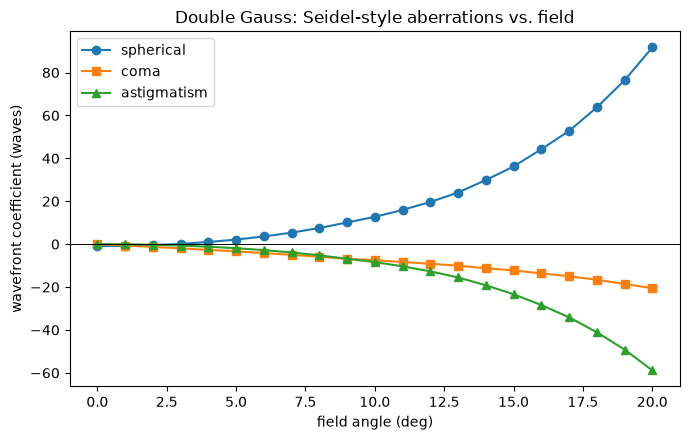

spherical (field-independent):  +23.5636 waves
coma (per unit field height):   -0.0045 waves/mm
astigmatism (per h^2):          -0.0000 waves/mm^2
field curvature (per h^2):      +0.0000 waves/mm^2
(design defocus offset:         -4.7522 waves)


In [5]:
from raytracer.analysis import seidel_coefficients

na_object_sine = 10.6 / abs(conjugate.object_z)  # entrance pupil radius / object distance
na_image = na_object_sine / abs(conjugate.magnification)
print(f"na_object_sine = {na_object_sine:.2e}, na_image = {na_image:.4f}")

seidel_fields_deg = np.linspace(0.0, 20.0, 21)
seidel_fields_mm = np.abs(conjugate.object_z) * np.tan(np.deg2rad(seidel_fields_deg))
seidel = seidel_coefficients(
    tracer, seidel_fields_mm, na_object_sine=na_object_sine, na_image=na_image,
    wavelength_mm=0.5876e-3,
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(seidel_fields_deg, seidel.spherical_waves, "o-", label="spherical")
ax.plot(seidel_fields_deg, seidel.coma_waves, "s-", label="coma")
ax.plot(seidel_fields_deg, seidel.astigmatism_waves, "^-", label="astigmatism")
ax.axhline(0, color="black", lw=0.7)
ax.set(xlabel="field angle (deg)", ylabel="wavefront coefficient (waves)",
       title="Double Gauss: Seidel-style aberrations vs. field")
ax.legend()
fig.tight_layout()
plt.show()

print(seidel.summary())

## Chromatic aberration (axial + lateral color)

SK4 resolves to a real measured `SellmeierMaterial` the same way as the
triplet's SK16; F4 stays the `AbbeMaterial` approximation. Sampled densely
across 400-700 nm (F/d/C marked for reference), not just at three points.

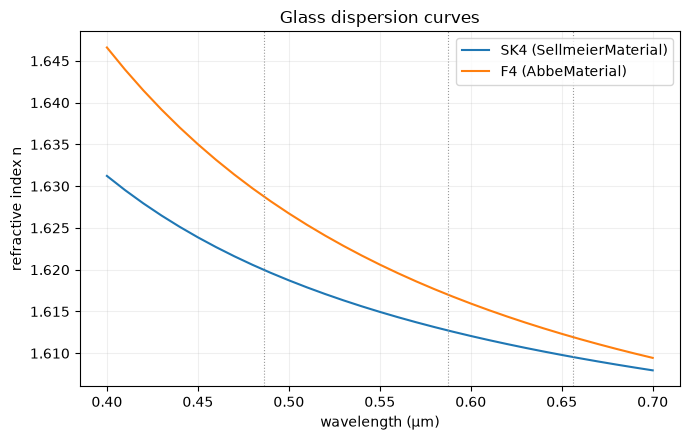

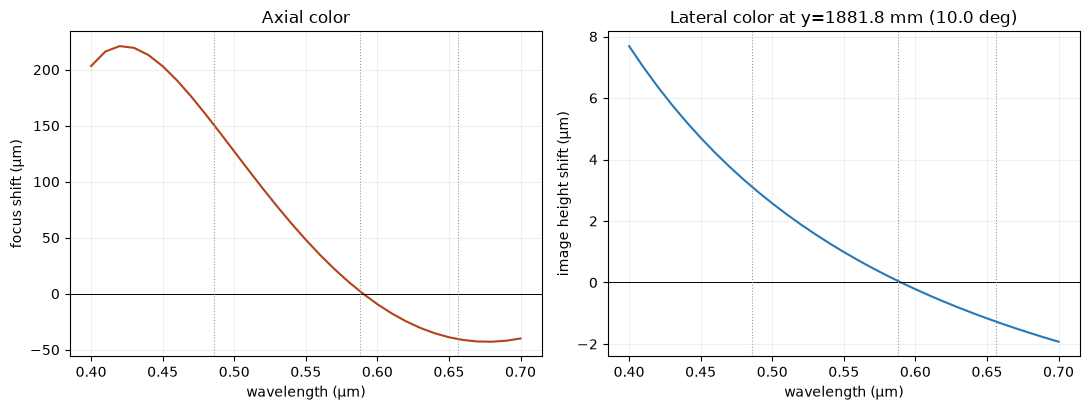

axial color (F to C):                +185.09 um
lateral color (F to C) at 10.0 deg:  +4.281 um


In [6]:
from raytracer.analysis import axial_color, lateral_color
from raytracer.core.materials import default_materials

WAVELENGTHS_UM = np.linspace(0.40, 0.70, 31)
F_LINE, D_LINE, C_LINE = 0.48613, 0.58756, 0.65627

materials = default_materials()
fig, ax = plt.subplots(figsize=(7, 4.5))
for name in (('SK4', 'F4')):
    glass = materials.resolve(name)
    n = [glass.index(wl) for wl in WAVELENGTHS_UM]
    ax.plot(WAVELENGTHS_UM, n, "-", label=f"{name} ({type(glass).__name__})")
for wl, label in [(F_LINE, "F"), (D_LINE, "d"), (C_LINE, "C")]:
    ax.axvline(wl, color="#999999", ls=":", lw=0.8)
ax.set(xlabel="wavelength (µm)", ylabel="refractive index n", title="Glass dispersion curves")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

ac = axial_color(system, WAVELENGTHS_UM, reference_wavelength_um=D_LINE)
y_field = np.abs(conjugate.object_z) * np.tan(np.deg2rad(10.0))
lc = lateral_color(system, WAVELENGTHS_UM, field_height_mm=y_field, reference_wavelength_um=D_LINE)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(WAVELENGTHS_UM, ac.focus_shift_mm * 1e3, "-", color="#b3421b")
axes[0].axhline(0, color="black", lw=0.7)
axes[1].plot(WAVELENGTHS_UM, lc.lateral_color_um, "-", color="#2878b5")
axes[1].axhline(0, color="black", lw=0.7)
for ax, title, ylabel in [
    (axes[0], "Axial color", "focus shift (µm)"),
    (axes[1], f"Lateral color at y={y_field:.1f} mm (10.0 deg)", "image height shift (µm)"),
]:
    for wl in (F_LINE, D_LINE, C_LINE):
        ax.axvline(wl, color="#999999", ls=":", lw=0.8)
    ax.set(xlabel="wavelength (µm)", ylabel=ylabel, title=title)
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

f_idx = int(np.argmin(np.abs(WAVELENGTHS_UM - F_LINE)))
c_idx = int(np.argmin(np.abs(WAVELENGTHS_UM - C_LINE)))
print(f"axial color (F to C):                {(ac.focus_shift_mm[f_idx] - ac.focus_shift_mm[c_idx]) * 1e3:+.2f} um")
print(f"lateral color (F to C) at 10.0 deg:  {(lc.lateral_color_um[f_idx] - lc.lateral_color_um[c_idx]):+.3f} um")
